In [16]:
# Cell 1: Setup and Imports
# This cell sets up the environment by installing necessary libraries and importing them.
# It's crucial for ensuring all required functionalities are available.

import os
import glob
from datetime import datetime, timedelta
import numpy as np
from PIL import Image # For opening images
from IPython.display import display, Image as IPythonImage # For displaying images in notebook
import cv2
import rasterio
from PIL import Image

import logging
import shutil # For file copying

# Configure logging for better tracking and debugging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logging.info("Initialized script for FLAME 3 image processing.")

# Define base paths for input and output.
# It's good practice to make these configurable.
INPUT_BASE_DIR = 'data/FLAME3_CV_Dataset_(Sycan_Marsh)/' # IMPORTANT: Change this to the actual path of your downloaded FLAME 3 dataset
OUTPUT_BASE_DIR = 'outputs/processed_flame3_dataset'

# Ensure output directory exists
os.makedirs(OUTPUT_BASE_DIR, exist_ok=True)
logging.info(f"Input base directory set to: {INPUT_BASE_DIR}")
logging.info(f"Output base directory set to: {OUTPUT_BASE_DIR}")

print("Setup complete. Ready to define utility functions.")

2025-07-26 12:30:08,984 - INFO - Initialized script for FLAME 3 image processing.
2025-07-26 12:30:08,986 - INFO - Input base directory set to: data/FLAME3_CV_Dataset_(Sycan_Marsh)/
2025-07-26 12:30:08,987 - INFO - Output base directory set to: outputs/processed_flame3_dataset


Setup complete. Ready to define utility functions.


In [17]:
# Cell 2: Utility Functions for Metadata Extraction and Thermal Image Regeneration
# These functions handle specific tasks like extracting timestamps from filenames
# and converting raw thermal JPGs to TIFFs, then regenerating a standardized JPG.

def extract_datetime_from_filename(filename):
    """
    Extracts datetime from FLAME 3 dataset filenames or EXIF metadata.
    For FLAME 3, the 'frame_XXXXX' prefix intrinsically pairs images.
    This function primarily serves as a placeholder for general datetime parsing
    from EXIF data if explicit time-based pairing is needed for other datasets.
    """
    try:
        img = Image.open(filename)
        exif_data = img._getexif()
        if exif_data:
            # EXIF tag 36864 is DateTimeOriginal, 306 is DateTime
            if 36864 in exif_data:
                dt_str = exif_data[36864]
            elif 306 in exif_data:
                dt_str = exif_data[306]
            else:
                logging.warning(f"No DateTimeOriginal or DateTime found in EXIF for {filename}. Using file modification time.")
                return datetime.fromtimestamp(os.path.getmtime(filename))
            
            # EXIF format is 'YYYY:MM:DD HH:MM:SS'
            return datetime.strptime(dt_str, '%Y:%m:%d %H:%M:%S')
        else:
            logging.warning(f"No EXIF data found for {filename}. Using file modification time.")
            return datetime.fromtimestamp(os.path.getmtime(filename))

    except Exception as e:
        logging.error(f"Error extracting datetime from {filename}: {e}. Returning None.", exc_info=True)
        return None

def extract_radiometric_thermal_data(raw_thermal_jpg_path):
    """
    Extracts radiometric thermal data. For FLAME 3, this primarily involves
    loading the provided Thermal TIFF, which contains per-pixel Celsius values.
    If the TIFF is not found, a warning is logged as deriving radiometric data
    from raw JPGs is complex without camera-specific calibration.
    """
    logging.info(f"Attempting to extract/load radiometric thermal data for {raw_thermal_jpg_path}...")
    
    # FLAME 3 provides a .TIFF directly. We will try to load the corresponding TIFF.
    base_name = os.path.splitext(raw_thermal_jpg_path)[0].replace('_thermal', '_thermal_tiff')
    thermal_tiff_path = base_name + '.TIFF'

    if os.path.exists(thermal_tiff_path):
        try:
            with rasterio.open(thermal_tiff_path) as src:
                thermal_data = src.read(1) # Read the first band (temperature values)
            logging.info(f"Successfully loaded thermal TIFF from {thermal_tiff_path}")
            return thermal_data
        except Exception as e:
            logging.error(f"Error loading thermal TIFF {thermal_tiff_path}: {e}", exc_info=True)
            return None
    else:
        logging.warning(f"Thermal TIFF not found at {thermal_tiff_path}. Cannot extract radiometric data from raw JPG without specific camera calibration info. This step may require specialized thermal image processing libraries or FLIR SDKs if the TIFF is genuinely missing.")
        return None

def regenerate_thermal_jpg_from_tiff(thermal_tiff_data, output_jpg_path, color_map=cv2.COLORMAP_JET):
    """
    Regenerates a standardized thermal JPG from temperature values using a known colormap.
    This ensures consistency across different thermal images.
    The maximum temperature saturates at approximately 500 degrees Celsius.
    """
    logging.info(f"Regenerating thermal JPG for {output_jpg_path}...")
    if thermal_tiff_data is None:
        logging.error("No thermal TIFF data provided for regeneration.")
        return False

    # Normalize temperature data to 0-255 range for colormap application
    # Clip values to prevent extreme outliers from skewing the normalization, using max 500C from dataset info.
    clipped_data = np.clip(thermal_tiff_data, 0, 500)
    
    # Simple linear scaling to 0-255 for visualization
    normalized_data = cv2.normalize(clipped_data, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)
    
    # Apply colormap
    colored_image = cv2.applyColorMap(normalized_data, color_map)

    try:
        cv2.imwrite(output_jpg_path, colored_image)
        logging.info(f"Successfully regenerated thermal JPG: {output_jpg_path}")
        return True
    except Exception as e:
        logging.error(f"Error regenerating thermal JPG {output_jpg_path}: {e}", exc_info=True)
        return False

print("Utility functions defined.")

Utility functions defined.


In [18]:
# Cell 3: Image Alignment Function

def align_rgb_to_thermal(raw_rgb_image_path, thermal_image_size, output_rgb_path, corrected_fov_rgb_path=None):
    """
    Scales, crops, and translates RGB images to align with thermal images.
    Prioritizes using the 'Corrected FOV RGB Image' if its path is provided and it exists.
    Falls back to processing the 'Raw RGB Image' if the corrected version is not available or fails.
    """
    logging.info(f"Attempting to align RGB image for input: {raw_rgb_image_path} to thermal size {thermal_image_size}...")

    # Prioritize using the 'Corrected FOV RGB Image' if its path is provided and it exists
    if corrected_fov_rgb_path and os.path.exists(corrected_fov_rgb_path):
        try:
            img = cv2.imread(corrected_fov_rgb_path)
            if img is None:
                raise FileNotFoundError(f"Could not read corrected RGB image at {corrected_fov_rgb_path}")
            
            # Ensure it's already the correct size (640x512 for FLAME 3 thermal)
            if img.shape[0:2] != (thermal_image_size[1], thermal_image_size[0]): # height, width
                img = cv2.resize(img, thermal_image_size, interpolation=cv2.INTER_AREA)
            
            cv2.imwrite(output_rgb_path, img)
            logging.info(f"Successfully used pre-corrected RGB image from {corrected_fov_rgb_path} and saved to {output_rgb_path}")
            return True
        except Exception as e:
            logging.warning(f"Error loading/processing corrected RGB {corrected_fov_rgb_path}: {e}. Falling back to raw RGB processing.", exc_info=True)

    # Fallback: Process the Raw RGB Image if corrected version not found or failed
    try:
        raw_rgb_img = cv2.imread(raw_rgb_image_path)
        if raw_rgb_img is None:
            raise FileNotFoundError(f"Could not read raw RGB image at {raw_rgb_image_path}")

        raw_h, raw_w = raw_rgb_img.shape[0:2]
        target_w, target_h = thermal_image_size

        # Calculate scaling factor to fit the smaller dimension
        scale_w = target_w / raw_w
        scale_h = target_h / raw_h
        scale_factor = max(scale_w, scale_h) # Use max to ensure target size is covered, then crop

        resized_w = int(raw_w * scale_factor)
        resized_h = int(raw_h * scale_factor)

        resized_img = cv2.resize(raw_rgb_img, (resized_w, resized_h), interpolation=cv2.INTER_AREA)

        # Calculate crop coordinates to center the image
        start_x = max(0, (resized_w - target_w) // 2)
        start_y = max(0, (resized_h - target_h) // 2)
        end_x = start_x + target_w
        end_y = start_y + target_h

        aligned_img = resized_img[start_y:end_y, start_x:end_x]

        # Ensure the final image is exactly the thermal_image_size
        if aligned_img.shape[0:2] != (target_h, target_w):
            aligned_img = cv2.resize(aligned_img, thermal_image_size, interpolation=cv2.INTER_AREA)

        cv2.imwrite(output_rgb_path, aligned_img)
        logging.info(f"Successfully aligned and saved RGB image from raw: {output_rgb_path}")
        return True

    except Exception as e:
        logging.error(f"Error aligning raw RGB image {raw_rgb_image_path}: {e}", exc_info=True)
        return False

print("Image alignment function defined.")

Image alignment function defined.


In [ ]:
# Cell 4: Main Processing Loop

def process_flame3_dataset(input_dir, output_dir):
    """
    Main function to process the FLAME 3 dataset, adapted for the new directory structure
    and simplified filename format (e.g., 00001.jpg, 00001.TIFF).
    It iterates through image quartets, performs required preprocessing steps,
    and saves the standardized outputs.
    """
    logging.info(f"Starting processing of FLAME 3 dataset from {input_dir}")
    
    # Discover all relevant files based on the NEW FLAME 3 directory structure
    # and the new filename format (e.g., 00001.jpg, 00001.TIFF)

    # Find Raw RGB files (e.g., data/FALME3_CV_Dataset_(Sycan_Marsh)/Fire/RGB/Raw/00001.jpg)
    raw_rgb_files = sorted(glob.glob(os.path.join(input_dir, '**', 'RGB', 'Raw', '*.jpg'), recursive=True))
    # Find Corrected FOV RGB files (e.g., data/FALME3_CV_Dataset_(Sycan_Marsh)/Fire/RGB/Corrected FOV/00001.jpg)
    corrected_fov_rgb_files = sorted(glob.glob(os.path.join(input_dir, '**', 'RGB', 'Corrected FOV', '*.jpg'), recursive=True))
    # Find Raw Thermal JPG files (e.g., data/FALME3_CV_Dataset_(Sycan_Marsh)/Fire/Thermal/Raw JPG/00001.jpg)
    raw_thermal_jpg_files = sorted(glob.glob(os.path.join(input_dir, '**', 'Thermal', 'Raw JPG', '*.jpg'), recursive=True))
    # Find Thermal TIFF (Celcius) files (e.g., data/FALME3_CV_Dataset_(Sycan_Marsh)/Fire/Thermal/Celcius TIFF/00001.TIFF)
    thermal_tiff_files = sorted(glob.glob(os.path.join(input_dir, '**', 'Thermal', 'Celsius TIFF', '*.TIFF'), recursive=True))

    logging.info(f"Found {len(raw_rgb_files)} raw RGB files.")
    logging.info(f"Found {len(corrected_fov_rgb_files)} corrected FOV RGB files.")
    logging.info(f"Found {len(raw_thermal_jpg_files)} raw thermal JPG files.")
    logging.info(f"Found {len(thermal_tiff_files)} thermal TIFF (Celsius) files.")

    # Create a mapping to pair files by their common base name (e.g., '00001')
    file_map = {}
    
    # Helper to get base name and category from path
    def get_info_from_path(file_path):
        parts = file_path.split(os.sep)
        # Assuming structure like .../Category/Subfolder/.../00001.jpg
        # Category is 'Fire' or 'No_Fire'
        category = None
        for i, part in enumerate(parts):
            if part in ['Fire', 'No_Fire']:
                category = part
                break
        
        # Extract base name without extension (e.g., '00001' from '00001.jpg')
        base_name = os.path.splitext(os.path.basename(file_path))[0]
        return 'No_Fire' # OR 'Fire', base_name

    for f in raw_rgb_files:
        category, base_name = get_info_from_path(f)
        if not category:
            logging.warning(f"Could not determine category for {f}. Skipping.")
            continue
        if base_name not in file_map:
            file_map[base_name] = {'category': category}
        file_map[base_name]['raw_rgb'] = f
        
    for f in corrected_fov_rgb_files:
        category, base_name = get_info_from_path(f)
        if not category: continue
        if base_name in file_map:
            file_map[base_name]['corrected_fov_rgb'] = f
            
    for f in raw_thermal_jpg_files:
        category, base_name = get_info_from_path(f)
        if not category: continue
        if base_name in file_map:
            file_map[base_name]['raw_thermal_jpg'] = f
            
    for f in thermal_tiff_files:
        category, base_name = get_info_from_path(f)
        if not category: continue
        if base_name in file_map:
            file_map[base_name]['thermal_tiff'] = f

    processed_count = 0
    THERMAL_IMG_SIZE = (640, 512) # width, height as per FLAME 3 dataset [cite: Table 1]

    for base_name, files_info in sorted(file_map.items()): # Sort to ensure consistent processing order
        logging.info(f"Processing image quartet: {base_name} (Category: {files_info.get('category', 'Unknown')})")

        raw_rgb_path = files_info.get('raw_rgb')
        corrected_fov_rgb_path = files_info.get('corrected_fov_rgb')
        raw_thermal_jpg_path = files_info.get('raw_thermal_jpg')
        thermal_tiff_path = files_info.get('thermal_tiff')

        # Ensure all core files for a quartet are present
        if not raw_rgb_path or not raw_thermal_jpg_path or not thermal_tiff_path:
            logging.warning(f"Missing one or more essential files for quartet {base_name}. Skipping. "
                            f"Required: Raw RGB, Raw Thermal JPG, Thermal TIFF. Found: RGB={raw_rgb_path}, Corrected_FOV={corrected_fov_rgb_path}, RT_JPG={raw_thermal_jpg_path}, T_TIFF={thermal_tiff_path}")
            continue

        output_category_dir = os.path.join(output_dir, files_info['category'])
        os.makedirs(output_category_dir, exist_ok=True)

        # Define output paths for standardized files
        output_aligned_rgb_path = os.path.join(output_category_dir, f"{base_name}_aligned_rgb.jpg")
        output_regenerated_thermal_jpg_path = os.path.join(output_category_dir, f"{base_name}_regenerated_thermal.jpg")
        output_thermal_tiff_path = os.path.join(output_category_dir, f"{base_name}_thermal.tiff") # Copy the original radiometric TIFF for consistency

        # Step a & e: Pairing based on frame ID and copying to output folder
        logging.info(f"Pairing by base name: {base_name}")
        
        # Step b: Extracts radiometric thermal data and ensures TIFF is in output
        thermal_data = None
        if os.path.exists(thermal_tiff_path):
            try:
                with rasterio.open(thermal_tiff_path) as src:
                    thermal_data = src.read(1)
                shutil.copy(thermal_tiff_path, output_thermal_tiff_path) # Copy original TIFF
                logging.info(f"Copied original Thermal TIFF to {output_thermal_tiff_path}")
            except Exception as e:
                logging.error(f"Failed to read/copy original Thermal TIFF {thermal_tiff_path}: {e}", exc_info=True)
                # Fallback to attempt extraction from raw JPG if TIFF read/copy failed
                logging.warning(f"Attempting to extract radiometric data from raw thermal JPG as TIFF processing failed for {base_name}.")
                thermal_data = extract_radiometric_thermal_data(raw_thermal_jpg_path)
        else:
            logging.warning(f"Original Thermal TIFF not found at {thermal_tiff_path}. Attempting extraction from raw thermal JPG (may be incomplete without specific calibration).")
            thermal_data = extract_radiometric_thermal_data(raw_thermal_jpg_path)

        # Step c: Regenerates thermal JPG from temperature values with a known color map.
        if thermal_data is not None:
            regenerate_thermal_jpg_from_tiff(thermal_data, output_regenerated_thermal_jpg_path)
        else:
            logging.error(f"Could not process thermal data for {base_name}. Skipping thermal JPG regeneration.")

        # Step d: Scales, crops, and translates RGB images to align with thermal images.
        # Pass both raw_rgb_path and corrected_fov_rgb_path to the alignment function
        align_rgb_to_thermal(raw_rgb_path, THERMAL_IMG_SIZE, output_aligned_rgb_path, corrected_fov_rgb_path)
            
        processed_count += 1
        logging.info(f"Finished processing quartet {base_name}. Total processed: {processed_count}")

    logging.info(f"Finished processing all detected FLAME 3 image quartets. Total {processed_count} quartets processed.")
    print(f"Image processing complete. Check the '{output_dir}' directory for processed images.")

# To execute the processing, uncomment the following line and replace the placeholder path:
process_flame3_dataset(INPUT_BASE_DIR, OUTPUT_BASE_DIR)

2025-07-26 13:03:24,784 - INFO - Starting processing of FLAME 3 dataset from data/FLAME3_CV_Dataset_(Sycan_Marsh)/
2025-07-26 13:03:26,849 - INFO - Found 738 raw RGB files.
2025-07-26 13:03:26,849 - INFO - Found 738 corrected FOV RGB files.
2025-07-26 13:03:26,853 - INFO - Found 738 raw thermal JPG files.
2025-07-26 13:03:26,853 - INFO - Found 738 thermal TIFF (Celsius) files.
2025-07-26 13:03:26,882 - INFO - Processing image quartet: 00001 (Category: No_Fire)
2025-07-26 13:03:26,884 - INFO - Pairing by base name: 00001
2025-07-26 13:03:26,941 - INFO - Copied original Thermal TIFF to outputs/processed_flame3_dataset\No_Fire\00001_thermal.tiff
2025-07-26 13:03:26,944 - INFO - Regenerating thermal JPG for outputs/processed_flame3_dataset\No_Fire\00001_regenerated_thermal.jpg...
2025-07-26 13:03:26,954 - INFO - Successfully regenerated thermal JPG: outputs/processed_flame3_dataset\No_Fire\00001_regenerated_thermal.jpg
2025-07-26 13:03:26,957 - INFO - Attempting to align RGB image for inpu

Image processing complete. Check the 'outputs/processed_flame3_dataset' directory for processed images.


--- Verifying Sample Output in: outputs/processed_flame3_dataset (using alternative visualization) ---

Contents of output directory:
- Fire
- No_Fire

Displaying sample processed images from 'No_Fire':
--- Processed Aligned RGB Image ---


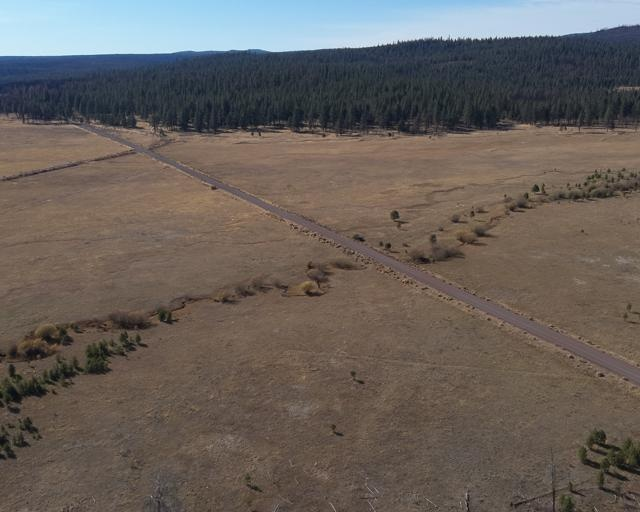


--- Processed Regenerated Thermal Image ---


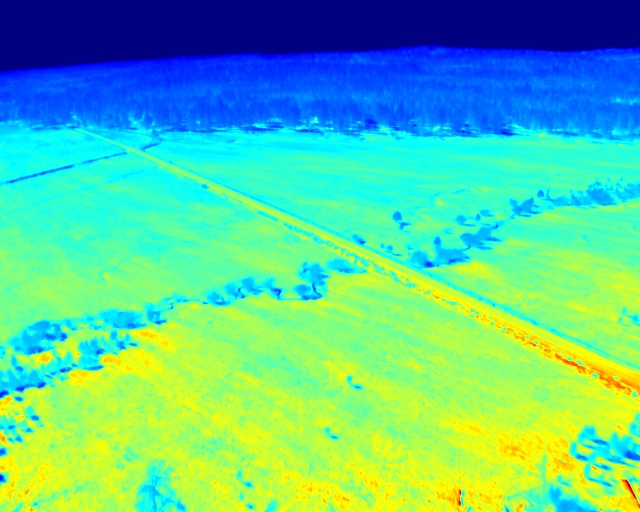


If images do not appear, ensure Pillow is installed: `pip install Pillow`
And ensure the processing cell (Cell 4) ran successfully.

--- Sample Output Verification Complete ---


In [30]:
# Cell 5: Print Sample Output (Alternative Visualization Method)
# Ensure OUTPUT_BASE_DIR is defined and accessible from previous cells
# If running this cell independently, you might need to define it here:
# OUTPUT_BASE_DIR = 'processed_flame3_dataset' # Example, replace with your actual output directory

print(f"--- Verifying Sample Output in: {OUTPUT_BASE_DIR} (using alternative visualization) ---")

# 1. List contents of the output directory
if os.path.exists(OUTPUT_BASE_DIR):
    print("\nContents of output directory:")
    for item in os.listdir(OUTPUT_BASE_DIR):
        print(f"- {item}")
else:
    print(f"Output directory '{OUTPUT_BASE_DIR}' does not exist. Please run the processing cell first.")

# 2. Find and display a sample processed image pair
sample_category = 'No_Fire' # Or 'Fire' 
sample_output_dir = os.path.join(OUTPUT_BASE_DIR, sample_category)

if os.path.exists(sample_output_dir):
    aligned_rgb_files = sorted(glob.glob(os.path.join(sample_output_dir, '*_aligned_rgb.jpg')))
    regenerated_thermal_files = sorted(glob.glob(os.path.join(sample_output_dir, '*_regenerated_thermal.jpg')))

    if aligned_rgb_files and regenerated_thermal_files:
        sample_rgb_path = aligned_rgb_files[0]
        sample_thermal_path = regenerated_thermal_files[0]

        print(f"\nDisplaying sample processed images from '{sample_category}':")
        
        try:
            print("--- Processed Aligned RGB Image ---")
            display(IPythonImage(filename=sample_rgb_path))
            
            print("\n--- Processed Regenerated Thermal Image ---")
            display(IPythonImage(filename=sample_thermal_path))
            
            print("\nIf images do not appear, ensure Pillow is installed: `pip install Pillow`")
            print("And ensure the processing cell (Cell 4) ran successfully.")

        except Exception as e:
            print(f"An error occurred while displaying sample images: {e}")
            print("Please ensure Pillow (`pip install Pillow`) is installed and images are valid.")
    else:
        print(f"No processed '_aligned_rgb.jpg' or '_regenerated_thermal.jpg' files found in '{sample_output_dir}'.")
        print("Please ensure the processing cell (Cell 4) ran successfully and created output files.")
else:
    print(f"Sample category directory '{sample_output_dir}' does not exist. This might mean no files were processed into this category.")

print("\n--- Sample Output Verification Complete ---")